<a href="https://colab.research.google.com/github/gyanendrasilwal0/ai-lab/blob/main/L1_2_ml_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

[Logistic regression](https://en.wikipedia.org/wiki/Logistic_regression) is similar to [linear regression](/blog/ml-linear-regression/), but instead of predicting a continuous output, classifies training examples by a set of categories or labels.  

For example, linear regression might be applied to predict the price of a house based on features like its size, number of bedrooms, and location. In contrast, logistic regression could be used to predict whether a house will sell within 30 days (yes or no). Like before, logistic regression is suited for questions with binary outcomes but can be extended to multiple categories, such as predicting whether a house will sell quickly, moderately, or slowly using multinomial logistic regression.

Here, I'm using the [Wine](https://archive.ics.uci.edu/ml/datasets/Wine) dataset from UCI. It maps thirteen continuous variables representing chemical contents of a wine to three labels, each a different winery in Italy.

## Loading and Plotting Data

We will use a dataset with a few chemical properties of wine.



# Simple Logistic Regression

Initially, I'm only using two features from the data set: alcohol and ash.  The labels are supplied as an array of data with values from `1` to `3`, but at first, I only want a simple regression problem with a yes or no answer.  

To do this, I first filter the data set, reducing it to only include wines with labels `1` or `2`.  Then, I use the scikit-learn `label_binarize` function, which takes an $m$-length list with $n$ possible values (two, in this case), and converts it to an $m \times n$ matrix, where each column represents one label with a value of `1`, and all others with a value of `0`.  I choose the first column, though the second would be equally valid here, just with the labels reversed.

I've provided a small example of `label_binarize` below, shuffling the whole input data set first (the examples are sorted by winery), and then selecting the first ten.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import label_binarize

data = pd.read_csv('data.txt')

# Filter the dataset for classes 1 and 2
reduced = data[data['class'] <= 2]

# Extract alcohol and ash columns
X = reduced[['alcohol', 'ash']].values

# Binarize the class labels (1 vs 2)
y = label_binarize(reduced['class'].values, classes=[1, 2])[:, 0]  # Corrected the classes argument

# Shuffle and binarize a subset of the original data
example = np.copy(data['class'].values)
np.random.shuffle(example)
example = example[0:10]
print('original:', example)

# Binarize the example labels
example = label_binarize(example, classes=list(set(example)))  # Ensure classes are passed correctly
print('binarized:', example)
print('1s vs all:', example[:, 0])


original: [3 3 2 2 2 2 3 3 2 3]
binarized: [[1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]]
1s vs all: [1 1 0 0 0 0 1 1 0 1]


The original array shows the shuffled wine class labels (1, 2, or 3).  
`label_binarize` converts these labels into a one-hot matrix, with one column per class.  
Each row has a single `1` indicating the wine’s class.  
Selecting the first column gives a binary label: `1` means class 1, `0` means not class 1.


I also split the data into training and testing sets before going further.  A simple way to do this is with the `train_test_split` function from scikit-learn, which allows me to specify a percentage (here 25%) to sample randomly from the data set and partition away for testing.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
print('train:', len(X_train), 'test:', len(X_test))

train: 97 test: 33


Because I'm going to be drawing a lot of data plots, I define a function that takes an $n \times 2$ array of data points `xy`, and an $n \times 1$ array `labels` to vary the symbol and color for each point.  This function supports three distinct labels, sufficient for this data set.

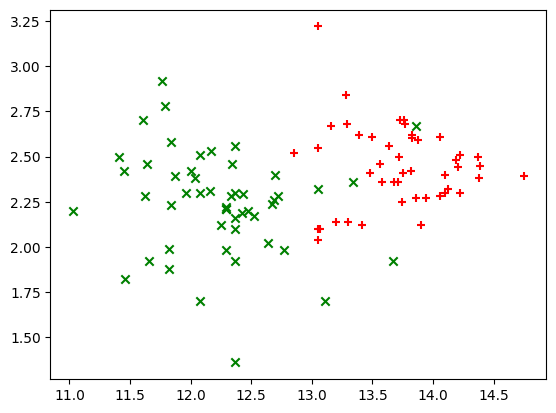

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

MARKERS = ['+', 'x', '.']
COLORS = ['red', 'green', 'blue']

def plot_points(xy, labels):

    for i, label in enumerate(set(labels)):
        points = np.array([xy[j,:] for j in range(len(xy)) if labels[j] == label])
        marker = MARKERS[i % len(MARKERS)]
        color = COLORS[i % len(COLORS)]
        plt.scatter(points[:,0], points[:,1], marker=marker, color=color)

plot_points(X_train, y_train)

There's a fairly obvious area near the center of the plot where a line could divide the two colors of points with a small amount of error.


To implement logistic regression, I need a hypothesis function $h_\theta(x)$, a cost function $J(\theta)$, and a gradient function that computes the partial derivatives of $J(\theta)$.

In logistic regression, $h_\theta$ is the [sigmoid](https://www.quora.com/Logistic-Regression-Why-sigmoid-function) function.  The sigmoid function is bounded between 0 and 1, and produces a value that can be interpreted as a probability.  This value can also be a yes / no answer with a cross-over, or decision boundary, at 0.5:

$$
h_\theta(x) = \frac{1}{1 + e^{ \theta^Tx}}
$$

Using [mean squared error](https://en.wikipedia.org/wiki/Mean_squared_error) from linear regression isn't a good idea here, as the resulting cost function [isn't convex](http://mathworld.wolfram.com/SigmoidFunction.html) and so is not well-suited for gradient descent.  Instead, the difference of $h_\theta(x^i) - y^i$ is calculated differently for $y=0$ and $y=1$, and the result is [transformed](https://stackoverflow.com/questions/32986123/why-the-cost-function-of-logistic-regression-has-a-logarithmic-expression) [logarithmically](https://math.stackexchange.com/questions/886555/deriving-cost-function-using-mle-why-use-log-function) into a convex function:

$$
J(\theta) =-\frac{1}{m}\sum_{i=1}^{m}y^{i}\log(h_\theta(x^{i}))+(1-y^{i})\log(1-h_\theta(x^{i}))
$$

Fortunately, the [derivative](https://math.stackexchange.com/questions/477207/derivative-of-cost-function-for-logistic-regression) of this function is exactly the same as that of linear regression, just with a different $h_\theta(x)$:

$$
\frac{\partial}{\partial\theta_{j}}J(\theta) =\sum_{i=1}^{m}(h_\theta(x^{i})-y^i)x_j^i
$$

In [18]:
import numpy as np

def sigmoid(X):
    return 1 / (1 + np.exp(-X))

def cost(theta, X, y):
    theta = theta[:,None]
    y = y[:,None]

    hyp = sigmoid(X.dot(theta))
    # Clip probabilities to avoid log(0) or log(1)
    hyp = np.clip(hyp, 1e-10, 1 - 1e-10)
    pos = np.multiply(-y, np.log(hyp))
    neg = np.multiply((1 - y), np.log(1 - hyp))

    return np.sum(pos - neg) / (len(X))

def gradient(theta, X, y):
    theta = theta[:,None]
    y = y[:,None]

    error = sigmoid(X.dot(theta)) - y
    return X.T.dot(error) / len(X)

It's worth noting the treatment of `y` and `theta` above.  In each function, I explicitly convert each to an $n$ or $m \times 1$ `ndarray`, so the matrix operations work correctly.  An alternative is to use a numpy `matrix`, which has stricter linear algebra semantics and treats 1-dimensional matrices more like column vectors.  However, I found that it was awkward to get the matrix interface to work correctly with both the optimization function used below, and with TensorFlow.  The indexing syntax can be thought of as explicitly columnizing the array of parameters or labels.

Instead of manually writing a gradient descent, I use an optimization algorithm from Scipy called [`fmin_tnc`](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.optimize.fmin_tnc.html) to perform it.  This function takes as parameters the cost function, an initial set of parameters for $\theta$, the gradient function, and a tuple of args to pass to each.  I define a `train` function that prepends a columns of 1s to the training data (allowing for a bias parameter $\theta_0$), run the minimization function and return the first of its return values, final parameters for $\theta$.

In [5]:
from scipy.optimize import fmin_tnc

def train(X, y):
    X = np.insert(X, 0, np.ones(len(X)), axis=1)
    theta = np.zeros(X.shape[1])
    result = fmin_tnc(func=cost, x0=theta, fprime=gradient, args=(X, y))

    return result[0]

theta = train(X_train, y_train)
print('theta: ', theta)

theta:  [65.60836679 -4.49324724 -3.02627318]


# Decision Boundaries and Evaluation


I can evaluate the results of the optimization visually and statistically, but I also need one more function: `predict`, which takes an array of examples `X` and learned parameter values `theta` as inputs and returns the predicted label for each.  Here too, 1s must be prepended to the inputs, and I return an integer value representing whether the result of the `sigmoid` hypothesis function is equal to or greater than 0.5.

To test the results of those predictions, Scikit-learn provides three functions to calculate [accuracy, precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall).  The test data from earlier is used here, so the results represent the performance of the classifier on unseen data.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def predict(X, theta):
    X = np.insert(X, 0, np.ones(len(X)), axis=1)
    return (sigmoid(X.dot(theta)) >= 0.5).astype(int)

predictions = predict(X_test, theta)

print('accuracy:', accuracy_score(y_test, predictions))
print('precision:', precision_score(y_test, predictions, average='macro'))
print('recall:', recall_score(y_test, predictions, average='macro'))

accuracy: 0.9393939393939394
precision: 0.9333333333333333
recall: 0.95


It's much more interesting to review the results visually, at least while the number of features is limited to two.  To do this, I need to plot the input points again, then overlay the decision boundary on top.  I tried several approaches for this in Matplotlib, and found that an unfilled countour plot gave me the best results.  This can also be done by manually calculating the function to plot, or using a filled contour plot that shades over the actual areas, but doing the math by hand is tedious, and the colormaps for filled contour plots leave a lot to be desired visually.

Below, I define a function `plot_boundary` that takes $n \times 2$ matrix of feature values $(x_0, x_1)$ and a prediction function, then builds a mesh grid of $(x, y)$ points corresponding to possible $(x_0, x_1)$ values within the input range.  After running the prediction function on all of them, the result is an $(x, y, z)$ point in space.  Because the result isn't continuous and flips directly from 0 to 1, there's only one contour that can be drawn on the plot: the decision boundary.

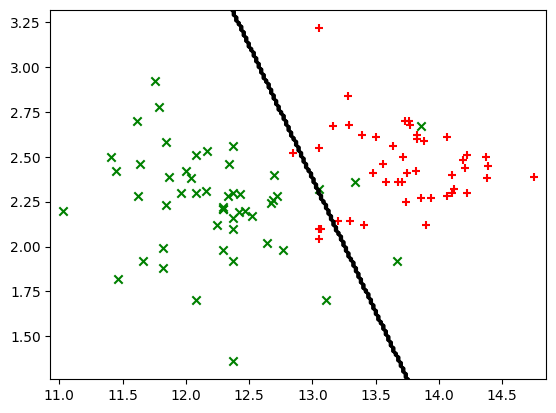

In [8]:
from matplotlib import cm

def plot_boundary(X, pred):

    x_min, x_max = X[:,0].min() - .1, X[:,0].max() + .1
    y_min, y_max = X[:,1].min() - .1, X[:,1].max() + .1

    xs, ys = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    xys = np.column_stack([xs.ravel(), ys.ravel()])
    zs = pred(xys).reshape(xs.shape)

    plt.contour(xs, ys, zs, colors='black')

plot_points(X_train, y_train)
plot_boundary(X_train, lambda x: predict(x, theta))

# Multinomial Logistic Regression

With the basics working, the next step is something more interesting: a similar set of two features from the data set (this time alcohol and flavanoids), but with all three labels instead of two.  The only differences below in loading the data are that I no longer filter out rows with the third label, that I use the full output from `label_binarize`, resulting in an $m \times 3$ array for `y`.

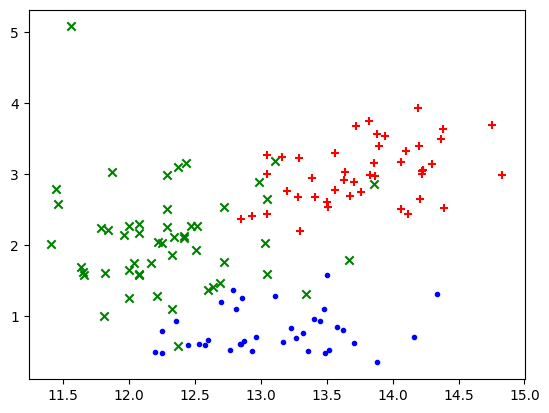

In [11]:
X = data[['alcohol', 'flavanoids']].values
y = data['class'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
y_train = label_binarize(y_train, classes=[1, 2, 3])

plot_points(X_train, y_train.argmax(axis=1))

The plotted data points again suggest some obvious linear boundaries between the wines.

It turns out that solving this as three one-vs-all problems is trivial, and re-uses all the code I just wrote.  Instead of one array of `theta` values I train three, one per problem, and then define a new `predict_multi` function that computes the three sigmoids for each example using each array of `theta` parameters.  This time, rather than return `1` or `0` based on whether the value is above or below 0.5, I return the `argmax` of each resulting row, the index of the largest value.

accuracy: 0.9333333333333333
precision: 0.932030932030932
recall: 0.9411027568922306


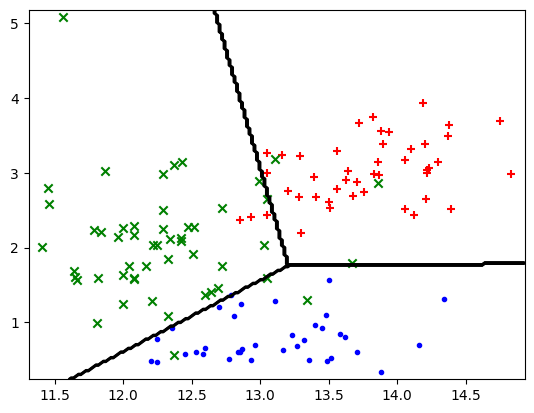

In [13]:
def predict_multi(X, thetas):
    X = np.insert(X, 0, np.ones(len(X)), axis=1)
    preds = [sigmoid(X.dot(t[:,None])) for t in thetas] # Changed np.asmatrix(t).T to t[:,None] and X * to X.dot
    return np.column_stack(preds).argmax(axis=1)

thetas = [train(X_train, y_train[:,i]) for i in range(0,3)]
predictions = predict_multi(X_test, thetas) + 1

print('accuracy:', accuracy_score(y_test, predictions))
print('precision:', precision_score(y_test, predictions, average='macro'))
print('recall:', recall_score(y_test, predictions, average='macro'))

plot_points(X_train, y_train.argmax(axis=1))
plot_boundary(X_train, lambda x: predict_multi(x, thetas))

Looking at the plot above, it seems like the boundaries could be much more accurate if they didn't have to be straight lines.  To allow for this, I define a function `transform` to add some polynomial features, converting each input example of $(x_0, x_1)$ to $(x_0, x_1, x_2, x_3, x_4)$, where $x_2 = x_0^2$, $x_3 = x_1^2$ and $x_4 = x_0x_1$.

accuracy: 0.9555555555555556
precision: 0.9521367521367522
recall: 0.9649122807017544


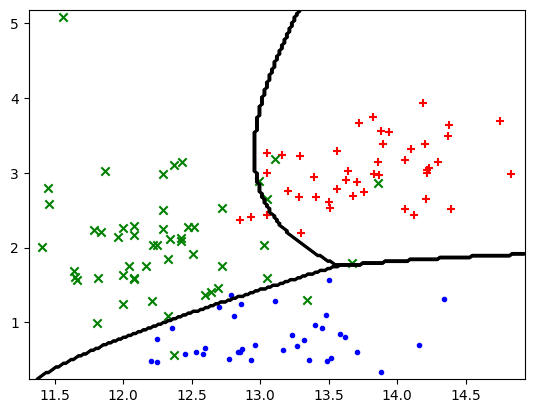

In [14]:
def transform_x(x):
    return [x[0], x[1], x[0] ** 2, x[1] ** 2, x[0] * x[1]]

def transform(X):
    return np.apply_along_axis(transform_x, 1, X)

X_train = transform(X_train)
X_test = transform(X_test)

thetas = [train(X_train, y_train[:,i]) for i in range(0,3)]
predictions = predict_multi(X_test, thetas) + 1

print('accuracy:', accuracy_score(y_test, predictions))
print('precision:', precision_score(y_test, predictions, average='macro'))
print('recall:', recall_score(y_test, predictions, average='macro'))

plot_points(X_train, y_train.argmax(axis=1))
plot_boundary(X_train, lambda x: predict_multi(transform(x), thetas))

# Regularization

Next, I want to include all the features from the data set.  To do this, instead of specifying what columns I want to include, I use `drop` to include everything except the `class` column.

Because I'm now significantly increasing the number of features, I apply [regularization](https://www.quora.com/What-is-regularization-in-machine-learning) as part of new cost and gradient functions.  Regularization prevents overfitting, a situation where a large number of features allows the classifier to fit the training set *too* exactly, meaning that it fails to generalize well and perform accurately on data it hasn't yet seen.

To avoid this problem, I add an additional term to the cost function and its gradient, representing the aggregated weights of each $\theta$ parameter.  Adding this term effectively increases the cost, meaning that the overall impact of feature weights is muted, and the fit to the training set is softened.  Note that for each of the new cost and gradient functions, the summation for regularization starts at $j = 1$, since the constant bia parameter $\theta_0$ is typically not regularized:

$$
J(\theta) =-\frac{1}{m}\sum_{i=1}^{m}[y^{i}\log(h_\theta(x^{i}))+(1-y^{i})\log(1-h_\theta(x^{i}))] + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2 \\
\frac{\partial}{\partial\theta_{j}}J(\theta) =\sum_{i=1}^{m}(h_\theta(x^{i})-y^i)x_j^i + \frac{\lambda}{m}\theta_j
$$

Below, I define the new cost and gradient functions, as well as a new function to train the classifier, given the addition of a new parameter `l`, for $\lambda$.  This parameter can be adjusted to change the effect of regularization; here I'm just using `1.0`.  In each case, I ensure that $\theta_0$ isn't regularized by creating a temporary `theta_reg`, starting with a zero followed by elements one and onward from `theta`.

In [22]:
X = data.drop('class', axis=1).values
y = data.values[:, data.columns.get_loc('class')]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
y_train = label_binarize(y_train, classes=[1, 2, 3])

def cost_reg(theta, X, y, lambda_):
    theta_reg = np.array((0, *theta[1:]))[:,None]
    reg = lambda_ * np.square(theta_reg).sum() / (2 * len(X))

    return cost(theta, X, y) + reg

def gradient_reg(theta, X, y, lambda_):
    theta_reg = np.array((0, *theta[1:]))[:,None]
    reg = lambda_ * theta_reg / len(X)

    return gradient(theta, X, y) + reg

def train_reg(X, y, lambda_):
    X = np.insert(X, 0, np.ones(len(X)), axis=1)
    theta = np.zeros(X.shape[1])
    result = fmin_tnc(func=cost_reg, x0=theta, fprime=gradient_reg, args=(X, y, lambda_))

    return result[0]

thetas = [train_reg(X_train, y_train[:,i], 1.0) for i in range(0,3)]
predictions = predict_multi(X_test, thetas) + 1

print('accuracy:', accuracy_score(y_test, predictions))
print('precision:', precision_score(y_test, predictions, average='macro'))
print('recall:', recall_score(y_test, predictions, average='macro'))

accuracy: 0.9111111111111111
precision: 0.921727395411606
recall: 0.9178921568627452


Regularization is a technique used to prevent overfitting when a model has many features. It works by adding a penalty to the cost function for large weights, which discourages the model from relying too heavily on any single feature. The strength of this penalty is controlled by a parameter `λ` (lambda)—larger `λ` shrinks weights more, making the model simpler and better at generalizing to new data, while smaller `λ` allows the model to fit the training data more closely. Importantly, the bias term (`θ₀`) is not penalized. By softening the influence of feature weights, regularization helps the model capture general patterns rather than memorizing the training set.


# Logistic Regression with TensorFlow

In this last section, I implement logistic regression using TensorFlow and test the model using the same data set.  TensorFlow allows for a significantly more compact and higher-level representation of the problem as a computational graph, resulting in less code and faster development of models.

One item definitely worth calling out is the use of the [`AdamOptimizer`](https://www.tensorflow.org/api_docs/python/tf/train/AdamOptimizer) instead of the [`GradientDescentOptimizer`](https://www.tensorflow.org/api_docs/python/tf/train/GradientDescentOptimizer) from the previous post.  Although the latter can still be used here, I found it a poor fit for two reasons:  it is *very* sensitive to learning rate and lambda parameters, and it converges extremely slowly.  Correct convergence required a very low learning rate (around 0.001 at most), and could still be seen decreasing at over 300,000 iterations, with a curve that appeared linear after the first thousand.  Poor tuning resulted in the optimizer spinning out of control and emitting `nan` values for all the parameters.

Using a different optimizer helped tremendously, especially one that is [adaptive](https://stackoverflow.com/questions/33919948/how-to-set-adaptive-learning-rate-for-gradientdescentoptimizer).  It converges significantly faster and requires much less hand-holding to do so.  Even then, these graphs take typically 25x the time to converge properly compared to the manual implementation above, and I'm not sure why this is the case.  Since Tensorflow does the calculus itself to find the gradient, it could be that this is the result of some issue or lack of optimization.  On the other hand, given that the platform is designed to distribute computations and scale to significantly larger data sets, this could be some overhead that is quite reasonable in those scenarios but is felt heavily in a small demonstration with a tiny number of examples.

I also adjusted all placeholders and variables to `tf.float64`, to avoid any issues with numerical precision.  After this and the adaptive optimizer, the results improved dramatically.

Because I want to build a few different graphs, I define a function that builds one given a few parameters: the number of features, the number of labels, and a lambda value for regularization.  This function `tf_create` builds a graph, and returns two functions itself: one to train the algorithm by running the optimizer, and another to predict labels for new values.  To compute the loss for regularization, I use the built-in `tf.nn.l2_loss` function, which is equivalent to the regularization loss I computed manually before.

In [25]:
import tensorflow as tf

def tf_create(n_features, n_labels, lambda_):

    # Variables for weights and bias
    weights = tf.Variable(tf.zeros([n_features, n_labels], dtype=tf.float64), name='weights')
    bias = tf.Variable(tf.zeros([n_labels], dtype=tf.float64), name='bias')

    # Optimizer
    optimizer = tf.keras.optimizers.Adam()

    # Define the prediction function (forward pass to get probabilities)
    @tf.function
    def compute_hyp(examples):
        logits = tf.matmul(examples, weights) + bias
        return tf.sigmoid(logits)

    # Define the loss function
    @tf.function
    def compute_loss(examples, labels):
        hyp = compute_hyp(examples)
        # Clip probabilities to avoid log(0) or log(1)
        hyp = tf.clip_by_value(hyp, 1e-10, 1 - 1e-10)
        loss_val = tf.reduce_mean(-labels * tf.math.log(hyp) - (1 - labels) * tf.math.log(1 - hyp))
        reg_loss = lambda_ * tf.nn.l2_loss(weights)
        return loss_val + reg_loss

    # Define the training step
    @tf.function
    def train_step(examples, labels):
        with tf.GradientTape() as tape:
            loss = compute_loss(examples, labels)
        gradients = tape.gradient(loss, [weights, bias])
        optimizer.apply_gradients(zip(gradients, [weights, bias]))

    # Wrapper for the training loop
    def train_(X_data, y_data, iterations):
        X_tensor = tf.constant(X_data, dtype=tf.float64)
        y_tensor = tf.constant(y_data, dtype=tf.float64)
        for i in range(iterations):
            train_step(X_tensor, y_tensor)

    # Wrapper for prediction
    def predict_(X_data):
        X_tensor = tf.constant(X_data, dtype=tf.float64)
        hyp = compute_hyp(X_tensor)
        return tf.argmax(hyp, axis=1).numpy()

    return train_, predict_

First, I evaluate the model against the 2-feature, 3-label example from above.

accuracy: 0.9111111111111111
precision: 0.9222222222222222
recall: 0.9215686274509803


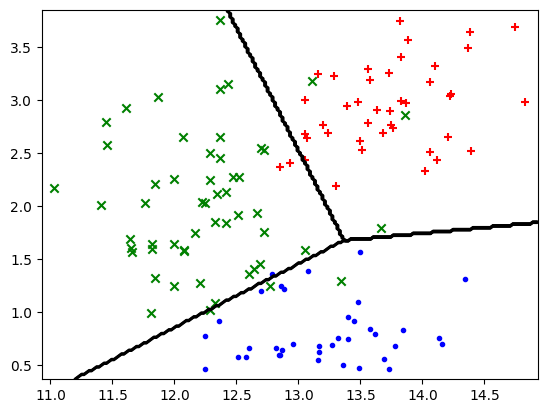

In [26]:
X = data[['alcohol', 'flavanoids']].values
y = label_binarize(data['class'], classes=[1, 2, 3])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

train_tf, predict_tf = tf_create(X.shape[1], y.shape[1], 0.0)

# No tf.Session() and tf.global_variables_initializer() needed in TensorFlow 2.x
train_tf(X_train, y_train, 30000)

predictions = predict_tf(X_test)
y_test_argmax = y_test.argmax(axis=1)

print('accuracy:', accuracy_score(y_test_argmax, predictions))
print('precision:', precision_score(y_test_argmax, predictions, average='macro'))
print('recall:', recall_score(y_test_argmax, predictions, average='macro'))

plot_boundary(X_train, lambda x: predict_tf(x))
plot_points(X_train, y_train.argmax(axis=1))

Next, I use the `transform` function to apply additional polynomial features to the dataset, allowing for a non-linear decision boundary.

accuracy: 0.9777777777777777
precision: 0.9761904761904763
recall: 0.9824561403508771


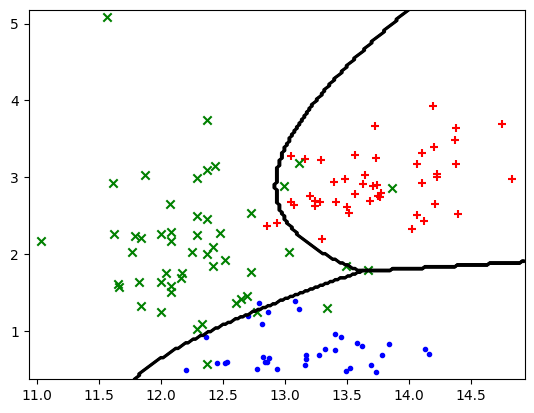

In [27]:
X = data[['alcohol', 'flavanoids']].values
X = transform(X)
y = label_binarize(data['class'], classes=[1, 2, 3])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

train_tf, predict_tf = tf_create(X.shape[1], y.shape[1], 0.0)

# No tf.Session() and tf.global_variables_initializer() needed in TensorFlow 2.x
train_tf(X_train, y_train, 30000)

predictions = predict_tf(X_test)
y_test_argmax = y_test.argmax(axis=1)

print('accuracy:', accuracy_score(y_test_argmax, predictions))
print('precision:', precision_score(y_test_argmax, predictions, average='macro'))
print('recall:', recall_score(y_test_argmax, predictions, average='macro'))

plot_points(X_train, y_train.argmax(axis=1))
plot_boundary(X_train, lambda x: predict_tf(transform(x)))

Finally, I include all the features from the data set, all the labels, and apply a small amount of regularization.

In [29]:
X = data.drop('class', axis=1).values
y = label_binarize(data['class'], classes=[1, 2, 3])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

train, predict = tf_create(X.shape[1], y.shape[1], 0.1)

# No tf.Session() and tf.global_variables_initializer() needed in TensorFlow 2.x
train(X_train, y_train, 30000)

predictions = predict(X_test)
y_test = y_test.argmax(axis=1)

print('accuracy:', accuracy_score(y_test, predictions))
print('precision:', precision_score(y_test, predictions, average='macro'))
print('recall:', recall_score(y_test, predictions, average='macro'))

accuracy: 0.9111111111111111
precision: 0.9027777777777778
recall: 0.888425925925926


# Reference
You can find the IPython notebook for this post on [GitHub](https://github.com/crsmithdev/notebooks/blob/master/ml-logistic-regression/ml-logistic-regression.ipynb).